<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Forward Modeling -- Wave propagation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# Q1.2 PINNs Forward

In [331]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
import torch.optim as optim



from tqdm import tqdm

In [332]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [333]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define parameters and initial conditions

dx = 0.01
dt = 0.005
x = torch.arange(0, 1 + dx, dx)
t = torch.arange(0, 2.0 + dt, dt)


x_scaled = x
t_scaled = t

dx_scaled = x_scaled[1] - x_scaled[0]
dt_scaled = t_scaled[1] - t_scaled[0]

x_grid, t_grid = torch.meshgrid(x_scaled, t_scaled, indexing='ij')

# Collocation points
x_colloc = x_grid.float().reshape(-1, 1).to(device)
t_colloc = t_grid.float().reshape(-1, 1).to(device)

c = 1.0
u_x0 = torch.sin(torch.pi * x_scaled) + 0.5 * torch.sin(3 * torch.pi * x_scaled)
du_dtx0 = torch.zeros(len(x_scaled))
u_0t = torch.zeros(len(t_scaled))
u_Lt = torch.zeros(len(t_scaled))

In [261]:
torch.tensor([[1,1,2],[3,4,5]]).flatten().reshape(2,3)

tensor([[1, 1, 2],
        [3, 4, 5]])

In [262]:
min(x_scaled)

tensor(0.)

In [263]:
# Test CFL condition
CFL = c * dt / dx

print(f"CFL number: {CFL}")
if CFL > 1:
    raise ValueError("CFL condition not met! Reduce dt or increase dx.")

CFL number: 0.5


In [264]:
CFL_scaled = c * dt_scaled / dx_scaled
print(f"CFL number: {CFL_scaled.item():.4f}")
if CFL_scaled > 1:
    raise ValueError("CFL condition not met in scaled coordinates! Reduce dt or increase dx.")

CFL number: 0.5000


In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=20, n_layers=8):
        super().__init__()
        
        layers = []
        layers.append(nn.Linear(2, hidden_size))  # Input: (x, t)
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: displacement u
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

In [266]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def physics_loss(model, x_colloc, t_colloc, c = 1.0):
    """Compute the physics-based loss for the wave equation"""
    # Enable gradients for collocation points
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)
    t_colloc = t_colloc.clone().detach().to(device).requires_grad_(True)

    # Predict displacement
    u_pred = model(torch.cat([x_colloc, t_colloc], dim=1))

    # First derivative
    dT_dx = torch.autograd.grad(outputs=u_pred, 
                            inputs=x_colloc, 
                            grad_outputs=torch.ones_like(u_pred), 
                            create_graph=True,
                            retain_graph=True)[0]

    dT_dt = torch.autograd.grad(outputs=u_pred, 
                            inputs=t_colloc,
                            grad_outputs=torch.ones_like(u_pred),
                            create_graph=True,
                            retain_graph=True)[0]
    
    # Second derivative
    d2T_dx2 = torch.autograd.grad(outputs=dT_dx, 
                               inputs=x_colloc, 
                               grad_outputs=torch.ones_like(dT_dx), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    d2T_dt2 = torch.autograd.grad(outputs=dT_dt, 
                               inputs=t_colloc, 
                               grad_outputs=torch.ones_like(dT_dt), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    # Wave equation residual: u_tt - c^2 * u_xx = 0
    residual = d2T_dt2 - (c ** 2) * d2T_dx2

    # Physics loss: Mean Squared Error of the residuals
    physics_loss_value = torch.mean(residual**2)

    return physics_loss_value

# Test the physics loss function
test_model = SimpleNN().to(device)

test_loss = physics_loss(test_model, x_colloc, t_colloc)

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Physics loss (untrained model): 0.000000
This is large since the model hasn't learned the physics yet!


In [300]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

n_boundary = len(t_scaled) * 2
n_initial = len(x_scaled)

def boundary_loss(model, n_boundary):
    """Compute the boundary condition loss"""
    t_bc = torch.linspace(0, 2, n_boundary).to(device).reshape(-1, 1)
    u_left = model(torch.cat([torch.ones_like(t_bc).to(device) * 0, t_bc], dim=1))
    u_right = model(torch.cat([torch.ones_like(t_bc).to(device), t_bc], dim=1))
    bc_loss = torch.mean(u_left**2 + u_right**2)
    return bc_loss


def initial_condition_loss(model, u_x0, n_initial):
    """Compute the initial condition loss"""
    # Initial displacement loss
    x_ic = torch.linspace(0, 1, n_initial).to(device).reshape(-1, 1)
    t_ic = torch.zeros_like(x_ic).to(device).reshape(-1, 1).requires_grad_(True)

    u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1))
    ic_loss = torch.mean((u_pred_ic.flatten() - u_x0.to(device))**2)

    # Initial velocity loss
    u_t_i = torch.autograd.grad(outputs=u_pred_ic, 
                                inputs=t_ic,
                                grad_outputs=torch.ones_like(u_pred_ic),
                                create_graph=True,
                                retain_graph=True)[0]
    
    ic_loss += 0.5 * torch.mean(u_t_i.flatten()**2)
    return ic_loss

def corner_loss(model):
    """Compute the corner condition loss"""
    corners_x  = torch.tensor([0., 0., 1., 1.]).to(device).reshape(-1, 1)
    corners_t  = torch.tensor([0., 2., 0., 2.]).to(device).reshape(-1, 1)
    corners = torch.cat([corners_x, corners_t], dim=1)
    u_corners = model(corners)
    corner_loss = torch.mean(u_corners**2)
    return corner_loss



# Test the boundary and initial condition loss function
test_model = SimpleNN().to(device)
bc_loss, ic_loss, c_loss = boundary_loss(test_model, n_boundary), initial_condition_loss(test_model, u_x0, n_initial), corner_loss(test_model)
print(f"Boundary loss (untrained model): {bc_loss.item():.6f}")
print(f"Initial condition loss (untrained model): {ic_loss.item():.6f}")
print(f"Corner loss (untrained model): {c_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Boundary loss (untrained model): 0.005823
Initial condition loss (untrained model): 0.699410
Corner loss (untrained model): 0.002922
This is large since the model hasn't learned the physics yet!


In [301]:
def train_model(model, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=5000, lr=1e-3, c=1.0, p_lambda=1.0
                , b_lambda=1.0, i_lambda=1.0, co_lambda=1.0):
    """Train the PINN model"""
    optimizer = optim.Adam(model.parameters(), lr=lr)

    physics_losses = []
    boundary_losses = []
    initial_losses = []
    corner_losses = []
    total_losses = []

    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()

        p_loss = physics_loss(model, x_colloc, t_colloc, c)
        b_loss = boundary_loss(model, n_boundary)
        i_loss = initial_condition_loss(model, u_x0, n_initial)
        c_loss = corner_loss(model)

        total_loss = p_lambda * p_loss + b_lambda * b_loss + i_lambda * i_loss + co_lambda * c_loss

        physics_losses.append(p_loss.item())
        boundary_losses.append(b_loss.item())
        initial_losses.append(i_loss.item())
        corner_losses.append(c_loss.item())
        total_losses.append(total_loss.item())

        total_loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Physics Loss: {p_loss.item():.6f}, Boundary Loss: {b_loss.item():.6f}, Initial Loss: {i_loss.item():.6f}, Corner Loss: {c_loss.item():.6f}")

    return model, physics_losses, boundary_losses, initial_losses, corner_losses, total_losses

Text(0.5, 1.0, 'Collocation Points')

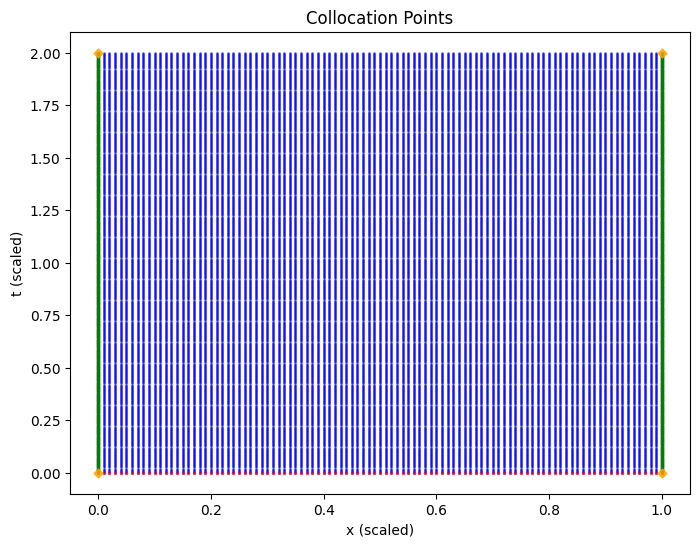

In [302]:
# Plot Collocation Points
plt.figure(figsize=(8, 6))

# Plot interior collocation points
plt.scatter(x_colloc.cpu().numpy(), t_colloc.cpu().numpy(), s=1, color='blue', alpha=0.5)

# Plot boundary collocation points
bc_t = torch.linspace(0, 2, n_boundary).to(device).reshape(-1, 1)
x_left = torch.ones_like(bc_t).to(device) * 0
x_right = torch.ones_like(bc_t).to(device)
plt.scatter(x_left.cpu().numpy(), bc_t.cpu().numpy(), s=4, color='green', alpha=0.5, marker='*', label='Boundary condition')
plt.scatter(x_right.cpu().numpy(), bc_t.cpu().numpy(), s=4, color='green', alpha=0.5, marker='*', label='Boundary condition')

# Plot initial condition points
ic_x = torch.linspace(0, 1, n_initial).to(device).reshape(-1, 1)
t_initial = torch.zeros_like(ic_x).to(device).reshape(-1, 1)
plt.scatter(ic_x.cpu().numpy(), t_initial.cpu().numpy(), s=4, color='red', alpha=0.5, marker='*', label='Initial condition')

# Plot corner points
corners_x  = torch.tensor([0., 0., 1., 1.]).to(device).reshape(-1, 1)
corners_t  = torch.tensor([0., 2., 0., 2.]).to(device).reshape(-1, 1)
plt.scatter(corners_x.cpu().numpy(), corners_t.cpu().numpy(), s=20, color='orange', alpha=0.8, marker='D', label='Corner condition')

plt.xlabel('x (scaled)')
plt.ylabel('t (scaled)')

plt.title('Collocation Points')

In [328]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

model = SimpleNN().to(device)

trained_model, physics_losses, boundary_losses, initial_losses, corner_losses, total_losses = train_model(
    model, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=15000, lr=1e-3
                            , p_lambda=1, b_lambda=5.0, i_lambda=5.0, co_lambda=5.0)

  0%|          | 6/15000 [00:00<13:13, 18.89it/s]  

Epoch 0, Total Loss: 3.540776, Physics Loss: 0.000000, Boundary Loss: 0.005823, Initial Loss: 0.699410, Corner Loss: 0.002922


  3%|▎         | 506/15000 [00:11<05:30, 43.80it/s]

Epoch 500, Total Loss: 0.784748, Physics Loss: 0.037587, Boundary Loss: 0.034757, Initial Loss: 0.107475, Corner Loss: 0.007200


  7%|▋         | 1006/15000 [00:22<05:00, 46.53it/s]

...

 93%|█████████▎| 14008/15000 [05:09<00:22, 44.62it/s]

Epoch 14000, Total Loss: 0.100316, Physics Loss: 0.008099, Boundary Loss: 0.012009, Initial Loss: 0.006232, Corner Loss: 0.000202


 97%|█████████▋| 14508/15000 [05:20<00:11, 44.13it/s]

Epoch 14500, Total Loss: 0.098564, Physics Loss: 0.008685, Boundary Loss: 0.012182, Initial Loss: 0.005577, Corner Loss: 0.000217


100%|██████████| 15000/15000 [05:31<00:00, 45.22it/s]


In [329]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Make predictions
with torch.no_grad():
    u_pred_flat = trained_model(torch.cat([x_colloc, t_colloc], dim=1))
    u_pred = u_pred_flat.reshape(x.shape[0], t.shape[0]).cpu().numpy()


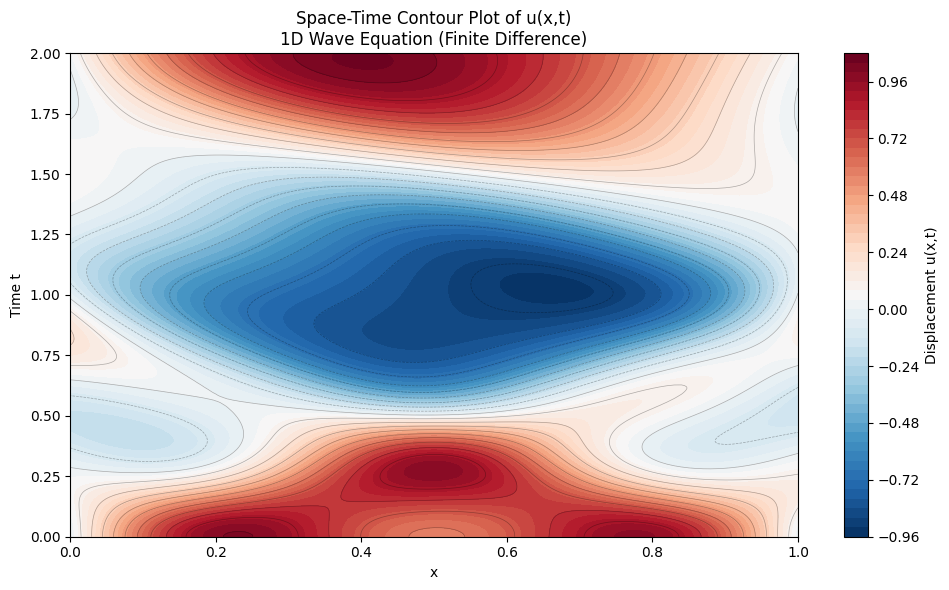

In [330]:
# Space-time contour plot
X, T_grid = np.meshgrid(x, t, indexing='ij')
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, T_grid, u_pred, levels=50, cmap='RdBu_r')
plt.colorbar(contour, label='Displacement u(x,t)')
plt.contour(X, T_grid, u_pred, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('Time t')
plt.title('Space-Time Contour Plot of u(x,t)\n1D Wave Equation (Finite Difference)')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Training Losses')

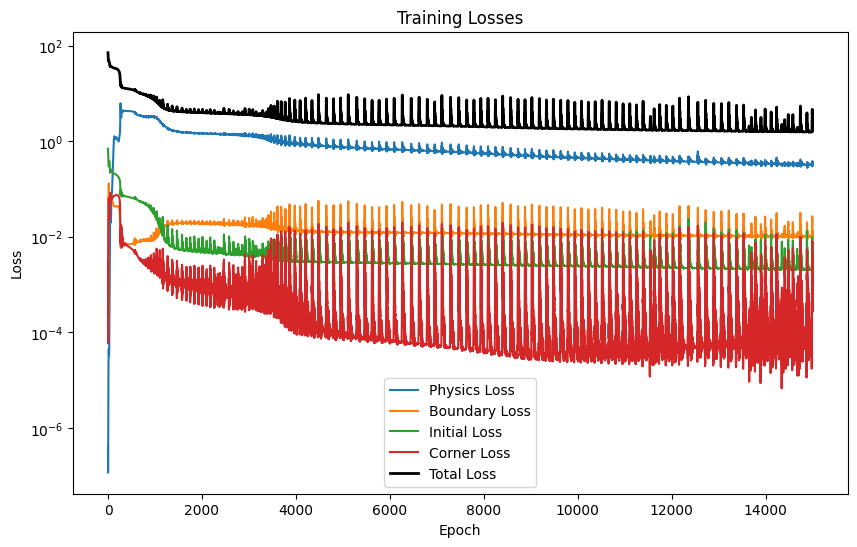

In [324]:
# Plot training losses
plt.figure(figsize=(10, 6))
plt.semilogy(physics_losses, label='Physics Loss')
plt.semilogy(boundary_losses, label='Boundary Loss')
plt.semilogy(initial_losses, label='Initial Loss')
plt.semilogy(corner_losses, label='Corner Loss')
plt.semilogy(total_losses, label='Total Loss', linewidth=2, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')